#### Task 1: Dataset Exploration

**Load dataset**

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

**1. How many samples and features are present in the dataset?**

**2. List the feature names and target classes.**

**3. Display the first five records.**

**Display the class distribution.**


In [2]:
print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])

print("\nFeature Names:")
print(iris.feature_names)

print("\nTarget Classes:")
print(iris.target_names)

print("\nFirst Five Records:")
print(X.head())

print("\nClass Distribution:")
print(y.value_counts())

Number of Samples: 150
Number of Features: 4

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

First Five Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


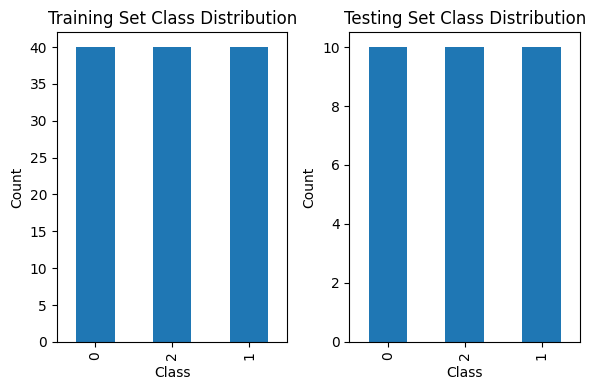

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar')
plt.title('Training Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind='bar')
plt.title('Testing Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### Task 2: Data Preparation


**1. Split the dataset into training (80%) and testing (20%) sets using random_state=42.**

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Set: (120, 4)
Testing Set : (30, 4)

Training Class Distribution:
target
0    40
2    40
1    40
Name: count, dtype: int64

Testing Class Distribution:
target
0    10
2    10
1    10
Name: count, dtype: int64


**2. Briefly explain why the dataset is divided into training and testing sets.**

The dataset is divided into training and testing sets to evaluate the model's ability to generalize to unseen data. The training set is used to learn patterns and relationships in the data, while the testing set is used to assess the model's performance on new samples. This helps detect overfitting and provides an unbiased estimate of the model's predictive accuracy.

#### Task 3: Building a Decision Tree Classifier

**1. Train a Decision Tree classifier using the default parameters.**

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**2. Predict the class labels for the test dataset.**

In [10]:
y_pred = dt_model.predict(X_test)

In [11]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,2,2
9,1,1


The first 10 predictions exactly match the actual class labels, indicating that the model has correctly learned the decision boundaries for these test samples.

In [12]:
print("Tree Depth :", dt_model.get_depth())
print("Leaf Nodes :", dt_model.get_n_leaves())

Tree Depth : 5
Leaf Nodes : 8


**Interpretation**

Tree Depth = 5

This means that the longest path from the root node to a leaf node consists of 5 decision levels.
A moderate depth like 5 suggests that the model is complex enough to capture patterns in the data without becoming excessively deep.

Leaf Nodes = 8

The trained tree contains 8 leaf nodes.
Each leaf node represents a final class prediction.

Overall, the Decision Tree has learned a reasonably complex model that partitions the feature space into 8 decision regions using 5 levels of decisions.

**3. Evaluate the model**

In [13]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Accuracy: 0.9333333333333333

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



**INTERPRETATION**

1. Accuracy = 93.33%

The Decision Tree classifier correctly classified 93.33% of the test samples. Out of 30 test samples, 28 were classified correctly.
This indicates that the model has learned the decision boundaries effectively and performs well on unseen data.

2. Confusion Matrix

* All 10 Setosa flowers were correctly classified.
* 9 Versicolor samples were correctly classified while 1 was incorrectly classified as Virginica.
* 9 Virginica samples were correctly classified while 1 sample was incorrectly classified as Versicolor.

This confusion is expected because Versicolor and Virginica have overlapping feature values, making them more difficult to separate than Setosa.

Overall Interpretation

The Decision Tree classifier achieved high performance with an overall accuracy of 93.33%. The model perfectly classified the Setosa class because it is well separated from the other two species. However, minor misclassifications occurred between Versicolor and Virginica due to the similarity in their petal and sepal measurements. Overall, the classifier demonstrates strong predictive performance on the Iris dataset.

#### Task 4: Visualizing the Decision Tree


**1. Visualize the trained Decision Tree using plot_tree().**

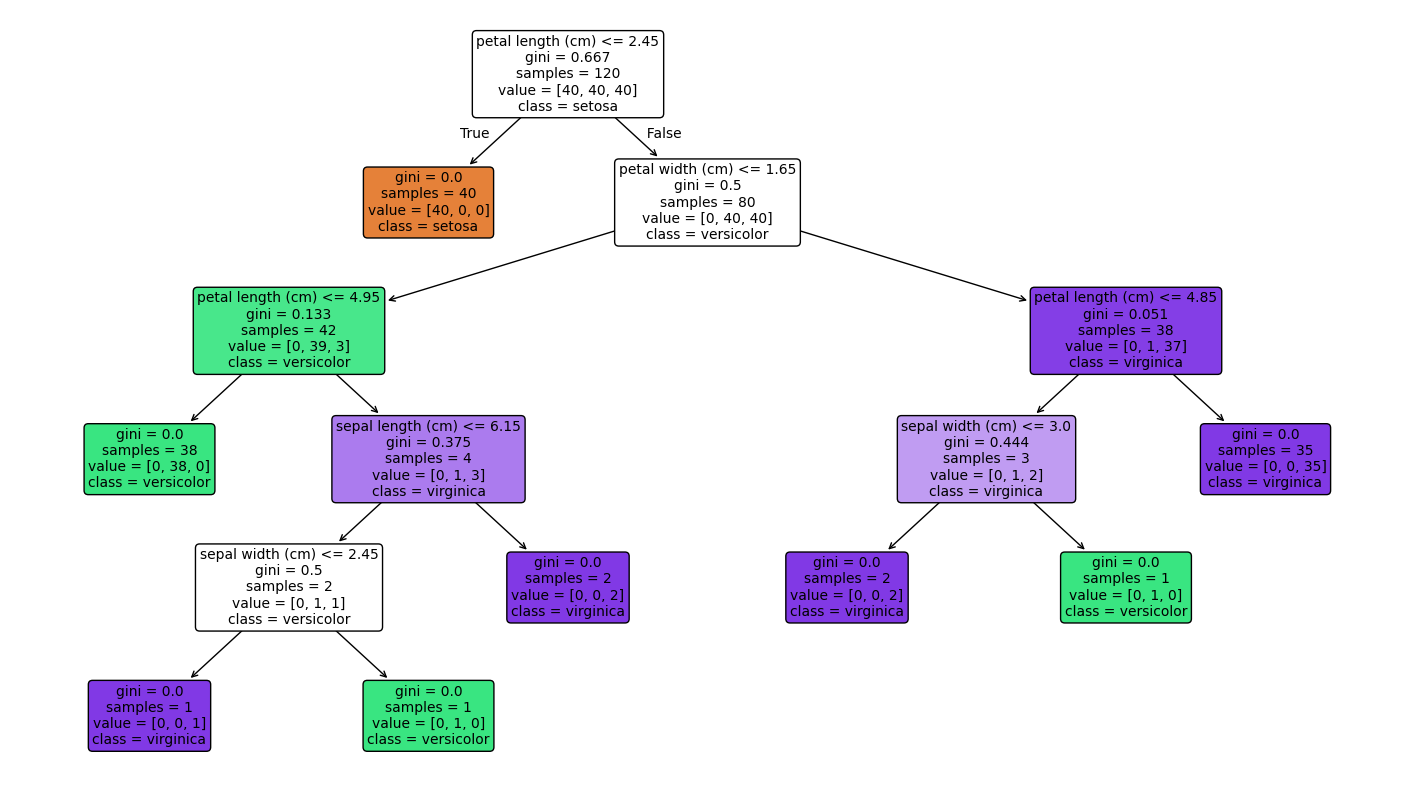

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

**2. From the visualization, identify:**

**Root node:** petal length (cm) ≤ 2.45

**Internal nodes:**

* petal width ≤ 1.65
* petal length ≤ 4.95
* petal length ≤ 4.85
* sepal length ≤ 6.15
* sepal width ≤ 2.45
* sepal width ≤ 3.0

**Leaf nodes:** 8 (Each leaf predicts one of: Setosa, Versicolor, Virginica)

**Maximum depth of the tree:** 5    


**Which feature is selected for the first split? Explain why you think this feature was chosen.**

The feature fo first split is petal length (cm) ≤ 2.45

The Decision Tree algorithm selects the feature that produces the highest information gain (or the largest reduction in Gini impurity, since the default criterion is Gini).

Among all four features, Petal Length best separates the three Iris species, especially Setosa, whose petal lengths are significantly smaller than those of Versicolor and Virginica. Splitting the data on Petal Length ≤ 2.45 cm immediately differentiates all Setosa samples. Therefore, the algorithm chooses Petal Length as the root feature.

#### Task 5: Comparing Gini Index and Entropy


In [15]:
from sklearn.tree import DecisionTreeClassifier

# Gini Model
gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_model.fit(X_train, y_train)

# Entropy Model
entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
gini_pred = gini_model.predict(X_test)
entropy_pred = entropy_model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

print("GINI MODEL")
print("Accuracy :", accuracy_score(y_test, gini_pred))
print("Tree Depth :", gini_model.get_depth())
print("Leaf Nodes :", gini_model.get_n_leaves())

print("\nENTROPY MODEL")
print("Accuracy :", accuracy_score(y_test, entropy_pred))
print("Tree Depth :", entropy_model.get_depth())
print("Leaf Nodes :", entropy_model.get_n_leaves())

GINI MODEL
Accuracy : 0.9333333333333333
Tree Depth : 5
Leaf Nodes : 8

ENTROPY MODEL
Accuracy : 0.9333333333333333
Tree Depth : 5
Leaf Nodes : 8


In [18]:
print("GINI Root Feature:")
print(iris.feature_names[gini_model.tree_.feature[0]])

print("\nENTROPY Root Feature:")
print(iris.feature_names[entropy_model.tree_.feature[0]])

GINI Root Feature:
petal length (cm)

ENTROPY Root Feature:
petal length (cm)


| Metric       | Gini Index            | Entropy               |
| ------------ | --------------------- | --------------------- |
| Accuracy     | **93.33%**            | **93.33%**            |
| Tree Depth   | **5**                 | **5**                 |
| Leaf Nodes   | **8**                 | **8**                 |
| Root Feature | **Petal Length (cm)** | **Petal Length (cm)** |

Neither criterion produced a simpler tree. Both Gini Index and Entropy generated Decision Trees with the same depth (5) and same number of leaf nodes (8), indicating equal model complexity.

Both criteria selected Petal Length (cm) because it provides the best separation among the Iris species, especially separating Setosa from the other two classes. This feature yields the highest impurity reduction (or information gain), making it the optimal choice for the first split.

#### Task 6: Effect of Maximum Tree Depth


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

depths = [1, 2, 3, 4, None]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append([
        depth,
        train_acc,
        test_acc,
        model.get_depth()
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Max Depth",
        "Training Accuracy",
        "Testing Accuracy",
        "Tree Depth"
    ]
)

results_df

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth
0,1.0,0.666667,0.666667,1
1,2.0,0.966667,0.933333,2
2,3.0,0.983333,0.966667,3
3,4.0,0.991667,0.933333,4
4,NaN,1.000000,0.933333,5


| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth | Observation                                                                                                   |
| --------- | ----------------: | ---------------: | ---------: | ------------------------------------------------------------------------------------------------------------- |
| **1**     |            66.67% |           66.67% |          1 | Underfitting. The tree is too shallow to capture the underlying patterns in the data.                         |
| **2**     |            96.67% |           93.33% |          2 | Good performance with a simple tree. Slight underfitting compared to deeper trees.                            |
| **3**     |        **98.33%** |       **96.67%** |          3 | Best generalization. High training and testing accuracy with balanced complexity.                             |
| **4**     |            99.17% |           93.33% |          4 | Slight overfitting. Training accuracy increases but testing accuracy decreases.                               |
| **None**  |           100.00% |           93.33% |          5 | Overfitting. The model perfectly memorizes the training data but does not improve performance on unseen data. |


**Question 1: Which model is underfitting?**

The model with max_depth = 1 is underfitting.

A depth of 1 allows only a single split, making the tree too simple to capture the relationships in the dataset. As a result, both the training accuracy (66.67%) and testing accuracy (66.67%) are low, indicating that the model fails to learn the underlying patterns.

**Question 2: Which model gives the best generalization?**

The model with max_depth = 3 provides the best generalization.

The training and testing accuracies are both high and close to each other, indicating that the model has learned the underlying patterns well without memorizing the training data. It strikes the best balance between model complexity and predictive performance.

**Question 3: Which model is likely to overfit?**

The model with max_depth = None is most likely to overfit.

When no maximum depth is specified, the tree continues growing until no further splits are possible. 

#### Task 7: Effect of min_samples_split


In [20]:
splits = [2, 5, 10, 20]

results = []

for split in splits:

    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append([
        split,
        accuracy_score(y_test, y_pred),
        model.get_depth(),
        model.get_n_leaves()
    ])

split_df = pd.DataFrame(
    results,
    columns=[
        "min_samples_split",
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes"
    ]
)

split_df

,min_samples_split,Accuracy,Tree Depth,Leaf Nodes
0,2,0.933333,5,8
1,5,0.966667,3,5
2,10,0.966667,3,5
3,20,0.966667,3,5


| min_samples_split | Accuracy | Tree Depth | Leaf Nodes | Observation                                                                  |
| ----------------: | -------: | ---------: | ---------: | ---------------------------------------------------------------------------- |
|             **2** |   93.33% |          5 |          8 | Deepest and most complex tree. Slight tendency to overfit.                   |
|             **5** |   96.67% |          3 |          5 | Simpler tree with better generalization and highest accuracy.                |
|            **10** |   96.67% |          3 |          5 | Similar performance to min_samples_split = 5; tree complexity remains low. |
|            **20** |   96.67% |          3 |          5 | Tree remains simple while maintaining high predictive performance.           |


min_samples_split specifies the minimum number of samples required for a node to be split into child nodes.



#### Task 8: Effect of min_samples_leaf


In [21]:
leaf_values = [1, 2, 5, 10]

results = []

for leaf in leaf_values:

    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append([
        leaf,
        accuracy_score(y_test, y_pred),
        model.get_depth(),
        model.get_n_leaves()
    ])

leaf_df = pd.DataFrame(
    results,
    columns=[
        "min_samples_leaf",
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes"
    ]
)

leaf_df

,min_samples_leaf,Accuracy,Tree Depth,Leaf Nodes
0,1,0.933333,5,8
1,2,0.933333,4,6
2,5,0.933333,3,5
3,10,0.933333,3,5


| min_samples_leaf | Accuracy | Tree Depth | Leaf Nodes | Observation                                                                               |
| ---------------: | -------: | ---------: | ---------: | ----------------------------------------------------------------------------------------- |
|            **1** |   93.33% |          5 |          8 | Deepest and most complex tree. Highest flexibility.                                       |
|            **2** |   93.33% |          4 |          6 | Slightly simpler tree with reduced depth and fewer leaves.                                |
|            **5** |   93.33% |          3 |          5 | Simpler tree that avoids very small leaf nodes.                                           |
|           **10** |   93.33% |          3 |          5 | Similar structure to `min_samples_leaf = 5`; increasing further does not change the tree. |


min_samples_leaf specifies the minimum number of samples that must be present in every leaf node.

#### Task 9: Answer the following questions.

**What is the role of the criterion parameter in a Decision Tree?**

The criterion parameter determines how the Decision Tree measures the quality of a split while constructing the tree. It selects the feature and threshold that produce the greatest reduction in impurity. Common criteria include Gini Index, which measures node impurity, and Entropy, which measures information gain. The criterion directly influences how decision boundaries are formed during training.

**How does max_depth influence underfitting and overfitting?**

max_depth controls the maximum number of levels in the Decision Tree. A very small depth restricts the tree from learning complex relationships, leading to underfitting. A very large depth allows the tree to continue splitting until nearly every training sample is correctly classified, which can cause overfitting. Choosing an appropriate depth helps balance model complexity and generalization.

**Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?**

Larger values of min_samples_split require more samples before a node can be split, while larger values of min_samples_leaf require each leaf node to contain more samples. These restrictions reduce unnecessary splits, resulting in fewer branches, lower tree depth, and fewer leaf nodes. Consequently, the Decision Tree becomes simpler and less prone to overfitting.

**Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.**

The max_depth hyperparameter had the greatest impact on model performance.
Changing max_depth significantly affected both training and testing accuracy, clearly demonstrating underfitting at depth 1 and overfitting when no depth limit was imposed. In contrast, changes in min_samples_split and min_samples_leaf mainly altered tree complexity, with relatively smaller effects on accuracy.

**Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.**

Based on the experimental results, the most suitable model is the Decision Tree with max_depth = 3. This model achieved the highest testing accuracy (96.67%) while maintaining a relatively simple tree structure. It provided the best balance between learning the training data and generalizing to unseen samples, avoiding both underfitting and overfitting. Therefore, max_depth = 3 is the recommended configuration for the Iris dataset.